In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
sns.set_theme(rc={"figure.figsize": (12, 5)})

In [2]:
df = pd.read_csv("Dataset.csv")

print(df.head())
print(df.shape)

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

## DATA ANALYSIS AND REMOVING EXTRA COLUMNS

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

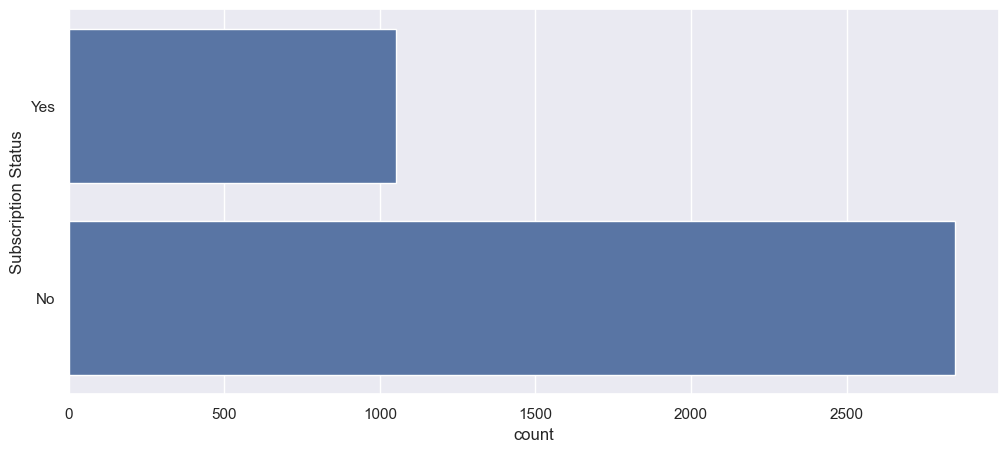

In [5]:
# Check subscription distribution
sns.countplot(df["Subscription Status"])
df["Subscription Status"].value_counts()

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

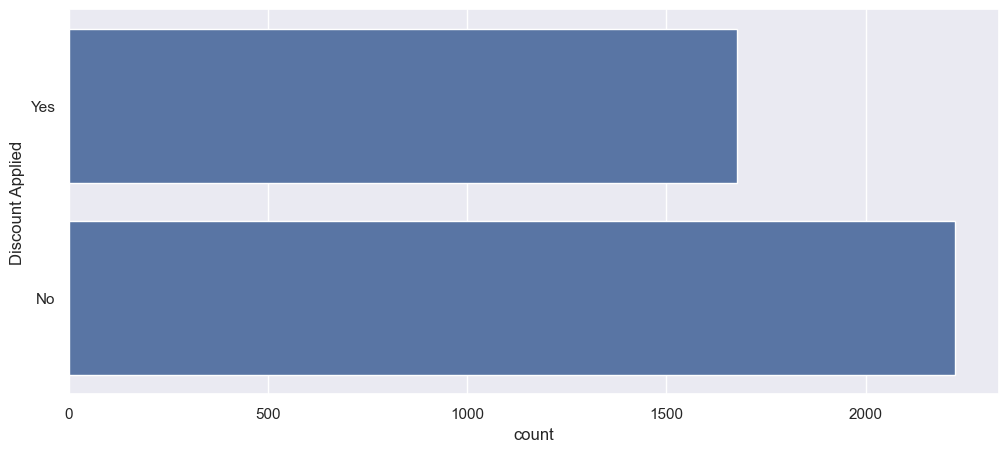

In [6]:
# Check discount applied distribution
sns.countplot(df["Discount Applied"])
df["Discount Applied"].value_counts()

Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64

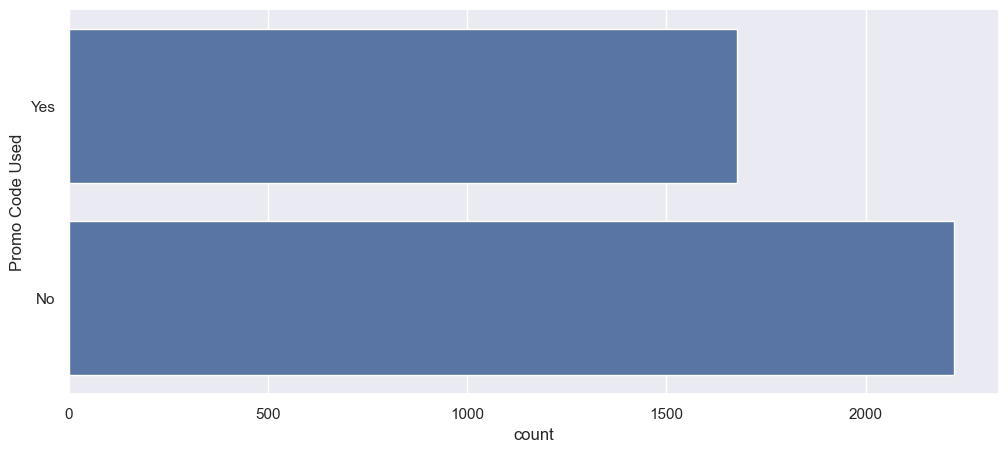

In [7]:
# Check promo code distribution
sns.countplot(df["Promo Code Used"])
df["Promo Code Used"].value_counts()

In [8]:
# Discount Applied and Promo Code Used are identical columns.
# Every subscriber uses a discount, 0 rows where subscriber has no discount.

df[
    (df["Subscription Status"] == "Yes") &
    (
        (df["Discount Applied"] == "No") |
        (df["Promo Code Used"] == "No")
    )
]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases


In [9]:
# Spot-check Store Pickup rows; it was mentioned the brand is a D@C company with no offline stores which is an inconsistency
df[df["Shipping Type"] == "Store Pickup"]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
10,11,53,Male,Shoes,Footwear,34,Arkansas,L,Purple,Fall,4.1,Yes,Store Pickup,Yes,Yes,26,Bank Transfer,Bi-Weekly
11,12,30,Male,Shorts,Clothing,68,Hawaii,S,Olive,Winter,4.9,Yes,Store Pickup,Yes,Yes,10,Bank Transfer,Fortnightly
15,16,64,Male,Skirt,Clothing,81,Rhode Island,M,Teal,Winter,2.8,Yes,Store Pickup,Yes,Yes,8,PayPal,Monthly
21,22,31,Male,Pants,Clothing,62,North Carolina,M,Charcoal,Winter,4.1,Yes,Store Pickup,Yes,Yes,22,Debit Card,Quarterly
22,23,56,Male,Pants,Clothing,37,California,M,Peach,Summer,3.2,Yes,Store Pickup,Yes,Yes,32,Debit Card,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3858,3859,30,Female,T-shirt,Clothing,77,Missouri,M,Olive,Winter,3.5,No,Store Pickup,No,No,26,Credit Card,Quarterly
3865,3866,25,Female,Shorts,Clothing,42,Nebraska,M,Olive,Spring,4.2,No,Store Pickup,No,No,28,Cash,Every 3 Months
3893,3894,21,Female,Hat,Accessories,64,Massachusetts,L,White,Fall,3.3,No,Store Pickup,No,No,29,Bank Transfer,Bi-Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly


In [10]:
print(df["Frequency of Purchases"].unique())

['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'Monthly'
 'Every 3 Months']


In [11]:
df["Frequency of Purchases"] = df["Frequency of Purchases"].replace("Every 3 months", "Quarterly")

In [12]:
print(df["Frequency of Purchases"].unique())

['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'Monthly'
 'Every 3 Months']


In [13]:
(df["Frequency of Purchases"] == "Every 3 Months").sum()

np.int64(584)

In [14]:
#no analytical value for customer intelligence or segmentation
df = df.drop(columns=['Color'])

In [15]:
# Exploratory checks on remaining columns
df["Size"].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [16]:
df["Location"].value_counts()

Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
Nebraska          87
New York          87
Nevada            87
Maryland          86
Delaware          86
Vermont           85
Louisiana         84
North Dakota      83
Missouri          81
West Virginia     81
New Mexico        81
Mississippi       80
Indiana           79
Georgia           79
Kentucky          79
Arkansas          79
North Carolina    78
Connecticut       78
Virginia          77
Ohio              77
Tennessee         77
Texas             77
Maine             77
South Carolina    76
Colorado          75
Oklahoma          75
Wisconsin         75
Oregon            74
Pennsylvania      74
Washington        73
Michigan          73
Alaska            72
Massachusetts     72
Wyoming           71
Utah              71
New Hampshire     71
South Dakota      70
Iowa              69
Florida           68
New Jersey        67
Hawaii            65
Ariz

In [17]:
df[df["Review Rating"].isnull()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
38,39,29,Male,Dress,Clothing,37,Florida,M,Winter,NaN,Yes,2-Day Shipping,Yes,Yes,44,Venmo,Every 3 Months
50,51,49,Male,Blouse,Clothing,28,Maryland,M,Spring,NaN,Yes,Store Pickup,Yes,Yes,39,Debit Card,Bi-Weekly
80,81,19,Male,Sandals,Footwear,72,New York,XL,Summer,NaN,Yes,Store Pickup,Yes,Yes,24,Credit Card,Every 3 Months
96,97,32,Male,Gloves,Accessories,73,Delaware,S,Spring,NaN,Yes,Express,Yes,Yes,43,Venmo,Every 3 Months
262,263,37,Male,Pants,Clothing,40,Hawaii,M,Summer,NaN,Yes,Next Day Air,Yes,Yes,6,Debit Card,Annually
330,331,46,Male,Sweater,Clothing,51,North Dakota,M,Winter,NaN,Yes,Express,Yes,Yes,43,Venmo,Bi-Weekly
356,357,56,Male,Pants,Clothing,80,Nevada,L,Spring,NaN,Yes,Standard,Yes,Yes,27,Cash,Weekly
383,384,50,Male,Sunglasses,Accessories,77,West Virginia,S,Fall,NaN,Yes,Standard,Yes,Yes,6,PayPal,Quarterly
419,420,53,Male,Shorts,Clothing,91,Utah,S,Winter,NaN,Yes,Free Shipping,Yes,Yes,14,Credit Card,Every 3 Months
442,443,29,Male,Sunglasses,Accessories,69,Michigan,M,Fall,NaN,Yes,Store Pickup,Yes,Yes,31,Credit Card,Quarterly


In [18]:
df["Payment Method"].value_counts()

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

In [19]:
df["Category"].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [20]:
# It was found customers purchasing winter items in the summer season
df[(df['Item Purchased'] == 'Sweater') & (df['Season'] == 'Summer')].sort_values('Review Rating', ascending=False)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
790,791,22,Male,Sweater,Clothing,37,Louisiana,M,Summer,4.9,Yes,Store Pickup,Yes,Yes,12,Bank Transfer,Quarterly
3479,3480,46,Female,Sweater,Clothing,56,New York,S,Summer,4.9,No,Standard,No,No,41,Cash,Monthly
1604,1605,18,Male,Sweater,Clothing,92,Maine,M,Summer,4.8,No,2-Day Shipping,Yes,Yes,25,Credit Card,Every 3 Months
18,19,52,Male,Sweater,Clothing,48,Montana,S,Summer,4.6,Yes,Free Shipping,Yes,Yes,17,Cash,Weekly
1434,1435,59,Male,Sweater,Clothing,64,New York,L,Summer,4.6,No,Free Shipping,Yes,Yes,21,Debit Card,Bi-Weekly
3587,3588,33,Female,Sweater,Clothing,90,Virginia,S,Summer,4.4,No,Standard,No,No,33,Debit Card,Annually
2010,2011,24,Male,Sweater,Clothing,21,Texas,M,Summer,4.4,No,2-Day Shipping,No,No,3,Debit Card,Bi-Weekly
722,723,27,Male,Sweater,Clothing,32,Wyoming,S,Summer,4.3,Yes,Store Pickup,Yes,Yes,50,Cash,Bi-Weekly
3132,3133,33,Female,Sweater,Clothing,97,Michigan,M,Summer,4.2,No,Express,No,No,26,Cash,Quarterly
899,900,65,Male,Sweater,Clothing,58,Rhode Island,M,Summer,4.0,Yes,Standard,Yes,Yes,20,PayPal,Annually


In [21]:
# Drop Promo Code Used — confirmed identical to Discount Applied
# Rename Discount Applied to unified column for clarity
df = df.drop(columns=['Promo Code Used'], errors='ignore')
df = df.rename(columns={'Discount Applied': 'Discount Applied/Promo Code Used'})

In [22]:
df["Item Purchased"].value_counts()

Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

In [23]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually


In [24]:
# Compute Tenure in weeks = Previous Purchases x interval per frequency
# Bi-Weekly = twice a week -> interval = 0.5 weeks
# Fortnightly = once a fortnight -> interval = 2 weeks
# Weekly = once a week -> interval = 1 week
# Monthly = once a month -> interval = 4 weeks
# Quarterly = once a quarter -> interval = 13 weeks (52/4)
# Annually = once a year -> interval = 52 weeks
conditions = [
    df['Frequency of Purchases'] == 'Fortnightly',
    df['Frequency of Purchases'] == 'Weekly',
    df['Frequency of Purchases'] == 'Annually',
    df['Frequency of Purchases'] == 'Quarterly',
    df['Frequency of Purchases'] == 'Bi-Weekly',
    df['Frequency of Purchases'] == 'Monthly'
]

values = [
    2  * df['Previous Purchases'],
    1  * df['Previous Purchases'],
    52 * df['Previous Purchases'],
    (52//4) * df['Previous Purchases'],
    0.5 * df['Previous Purchases'],
    4 * df['Previous Purchases']
]

df['Tenure in weeks'] = np.select(conditions, values, default=0)

In [25]:
df.sample(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
1172,1173,59,Male,Coat,Outerwear,68,Oregon,L,Spring,4.6,No,Store Pickup,Yes,42,Bank Transfer,Bi-Weekly,21.0
2963,2964,52,Female,Boots,Footwear,97,Maine,M,Spring,3.6,No,Free Shipping,No,28,Credit Card,Weekly,28.0
2956,2957,52,Female,Dress,Clothing,88,Montana,M,Fall,3.7,No,Standard,No,30,Venmo,Monthly,120.0
2629,2630,61,Male,Scarf,Accessories,44,New Hampshire,M,Winter,3.8,No,Free Shipping,No,25,Venmo,Annually,1300.0
1752,1753,34,Male,Boots,Footwear,29,South Dakota,L,Winter,3.3,No,Store Pickup,No,14,Venmo,Quarterly,182.0


In [26]:
df.sample(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
1506,1507,35,Male,Shirt,Clothing,30,South Carolina,L,Fall,3.0,No,2-Day Shipping,Yes,44,PayPal,Quarterly,572.0
2190,2191,42,Male,Belt,Accessories,75,Alaska,S,Spring,4.6,No,Express,No,33,Credit Card,Annually,1716.0
2639,2640,18,Male,Blouse,Clothing,35,New Hampshire,XL,Winter,2.6,No,Free Shipping,No,33,Debit Card,Quarterly,429.0
2514,2515,42,Male,Hat,Accessories,37,Alaska,L,Spring,4.8,No,Free Shipping,No,45,PayPal,Bi-Weekly,22.5
505,506,61,Male,T-shirt,Clothing,63,Maine,L,Spring,4.3,Yes,Express,Yes,9,Cash,Bi-Weekly,4.5
3274,3275,46,Female,Sweater,Clothing,20,Oklahoma,M,Spring,3.9,No,Store Pickup,No,14,Cash,Fortnightly,28.0
302,303,37,Male,Sweater,Clothing,44,Delaware,L,Summer,3.6,Yes,Express,Yes,27,Bank Transfer,Every 3 Months,0.0
2698,2699,55,Female,Hoodie,Clothing,57,Virginia,M,Summer,3.6,No,Store Pickup,No,34,Venmo,Quarterly,442.0
3116,3117,50,Female,Coat,Outerwear,66,Montana,L,Spring,3.7,No,Store Pickup,No,1,Venmo,Weekly,1.0
1802,1803,57,Male,Shorts,Clothing,96,Rhode Island,L,Winter,2.6,No,Store Pickup,No,31,Venmo,Bi-Weekly,15.5


In [27]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Tenure in weeks
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538,264.378333
std,1125.977353,15.207589,23.685392,0.716983,14.447125,522.585343
min,1.000000,18.000000,20.000000,2.500000,1.000000,0.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,10.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,43.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,196.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,2600.000000


In [28]:
# Spot-check minimum tenure value
df[df['Tenure in weeks']==0.5]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
187,188,19,Male,Shoes,Footwear,94,Georgia,S,Spring,3.3,Yes,Store Pickup,Yes,1,Bank Transfer,Bi-Weekly,0.5
1000,1001,43,Male,Socks,Clothing,46,Georgia,M,Winter,3.9,Yes,Express,Yes,1,Bank Transfer,Bi-Weekly,0.5
1263,1264,41,Male,Hoodie,Clothing,70,Delaware,L,Winter,4.6,No,2-Day Shipping,Yes,1,Credit Card,Bi-Weekly,0.5
1264,1265,52,Male,Sweater,Clothing,92,Vermont,S,Winter,2.5,No,Next Day Air,Yes,1,Venmo,Bi-Weekly,0.5
1385,1386,41,Male,Jewelry,Accessories,64,Mississippi,M,Fall,2.6,No,Store Pickup,Yes,1,Bank Transfer,Bi-Weekly,0.5
1663,1664,43,Male,Shirt,Clothing,22,Maine,XL,Summer,3.5,No,Standard,Yes,1,Cash,Bi-Weekly,0.5
2705,2706,65,Female,Jacket,Outerwear,81,Washington,S,Spring,5.0,No,Store Pickup,No,1,Credit Card,Bi-Weekly,0.5
2914,2915,45,Female,Sweater,Clothing,72,Pennsylvania,M,Fall,3.8,No,Express,No,1,Debit Card,Bi-Weekly,0.5
3329,3330,34,Female,Backpack,Accessories,54,New Jersey,M,Winter,3.8,No,Express,No,1,Debit Card,Bi-Weekly,0.5
3332,3333,27,Female,T-shirt,Clothing,23,Washington,M,Summer,3.1,No,2-Day Shipping,No,1,PayPal,Bi-Weekly,0.5


In [29]:
# Spot-check maximum tenure value
df[df['Tenure in weeks']==2600]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
124,125,44,Male,Sweater,Clothing,86,Nevada,M,Spring,3.1,Yes,Next Day Air,Yes,50,PayPal,Annually,2600.0
521,522,36,Male,Shorts,Clothing,41,Vermont,L,Winter,3.5,Yes,Standard,Yes,50,Bank Transfer,Annually,2600.0
639,640,54,Male,Dress,Clothing,24,Mississippi,L,Spring,4.0,Yes,2-Day Shipping,Yes,50,Credit Card,Annually,2600.0
665,666,41,Male,Pants,Clothing,55,New Mexico,M,Spring,4.9,Yes,2-Day Shipping,Yes,50,Credit Card,Annually,2600.0
1537,1538,68,Male,Shoes,Footwear,89,Alaska,L,Spring,3.2,No,Next Day Air,Yes,50,Venmo,Annually,2600.0
1623,1624,64,Male,Backpack,Accessories,58,Indiana,M,Summer,3.5,No,Next Day Air,Yes,50,Debit Card,Annually,2600.0
1639,1640,41,Male,Gloves,Accessories,65,Missouri,L,Summer,3.3,No,Free Shipping,Yes,50,PayPal,Annually,2600.0
2099,2100,31,Male,T-shirt,Clothing,78,Oklahoma,L,Summer,2.9,No,Express,No,50,PayPal,Annually,2600.0
2806,2807,45,Female,Blouse,Clothing,39,South Carolina,L,Spring,2.7,No,Standard,No,50,Credit Card,Annually,2600.0
2917,2918,58,Female,Shirt,Clothing,45,Colorado,XL,Winter,2.9,No,Store Pickup,No,50,Venmo,Annually,2600.0


In [30]:
# Check annual buyers sorted by purchase count — tenure sanity check
df[df['Frequency of Purchases'] == 'Annually'].sort_values('Previous Purchases', ascending=False)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
665,666,41,Male,Pants,Clothing,55,New Mexico,M,Spring,4.9,Yes,2-Day Shipping,Yes,50,Credit Card,Annually,2600.0
2806,2807,45,Female,Blouse,Clothing,39,South Carolina,L,Spring,2.7,No,Standard,No,50,Credit Card,Annually,2600.0
1623,1624,64,Male,Backpack,Accessories,58,Indiana,M,Summer,3.5,No,Next Day Air,Yes,50,Debit Card,Annually,2600.0
521,522,36,Male,Shorts,Clothing,41,Vermont,L,Winter,3.5,Yes,Standard,Yes,50,Bank Transfer,Annually,2600.0
2917,2918,58,Female,Shirt,Clothing,45,Colorado,XL,Winter,2.9,No,Store Pickup,No,50,Venmo,Annually,2600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3728,3729,62,Female,Jacket,Outerwear,31,Vermont,L,Winter,3.0,No,Standard,No,1,Debit Card,Annually,52.0
2174,2175,42,Male,Backpack,Accessories,49,Colorado,S,Spring,2.9,No,Store Pickup,No,1,Cash,Annually,52.0
1228,1229,55,Male,Jacket,Outerwear,55,Indiana,S,Winter,3.9,No,Express,Yes,1,Cash,Annually,52.0
1842,1843,61,Male,Handbag,Accessories,78,Alabama,M,Summer,4.4,No,Express,No,1,Debit Card,Annually,52.0


In [31]:
# Identify rows where tenure in years >= age — logically impossible
df[df['Tenure in weeks']/52 >= df['Age']]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
32,33,36,Male,Jacket,Outerwear,67,Kansas,M,Summer,4.9,Yes,Free Shipping,Yes,37,Venmo,Annually,1924.0
55,56,40,Male,Jacket,Outerwear,28,South Carolina,M,Winter,3.0,Yes,2-Day Shipping,Yes,49,Credit Card,Annually,2548.0
97,98,21,Male,Shoes,Footwear,92,Virginia,M,Winter,4.8,Yes,Store Pickup,Yes,37,Cash,Annually,1924.0
98,99,20,Male,Jeans,Clothing,67,New York,XL,Spring,2.6,Yes,Next Day Air,Yes,20,Bank Transfer,Annually,1040.0
119,120,38,Male,Coat,Outerwear,76,Wyoming,M,Fall,4.3,Yes,Express,Yes,44,Cash,Annually,2288.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3659,3660,27,Female,Sandals,Footwear,77,Illinois,S,Fall,4.9,No,Store Pickup,No,46,Bank Transfer,Annually,2392.0
3677,3678,32,Female,Backpack,Accessories,30,Michigan,M,Fall,2.8,No,Standard,No,43,Cash,Annually,2236.0
3778,3779,25,Female,Sneakers,Footwear,60,South Dakota,M,Fall,2.9,No,Free Shipping,No,30,Debit Card,Annually,1560.0
3804,3805,37,Female,Hat,Accessories,77,Florida,M,Fall,2.7,No,2-Day Shipping,No,45,Cash,Annually,2340.0


In [32]:
# Remove impossible rows: tenure in years must be less than age
df = df[df['Tenure in weeks']/52 < df['Age']]

In [33]:
# Confirm shape after removal — should be ~3780 rows
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3780 entries, 0 to 3899
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Customer ID                       3780 non-null   int64  
 1   Age                               3780 non-null   int64  
 2   Gender                            3780 non-null   object 
 3   Item Purchased                    3780 non-null   object 
 4   Category                          3780 non-null   object 
 5   Purchase Amount (USD)             3780 non-null   int64  
 6   Location                          3780 non-null   object 
 7   Size                              3780 non-null   object 
 8   Season                            3780 non-null   object 
 9   Review Rating                     3744 non-null   float64
 10  Subscription Status               3780 non-null   object 
 11  Shipping Type                     3780 non-null   object 
 12  Discount Ap

In [34]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,28.0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,4.0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,23.0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,49.0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,1612.0


<Axes: xlabel='Tenure in weeks'>

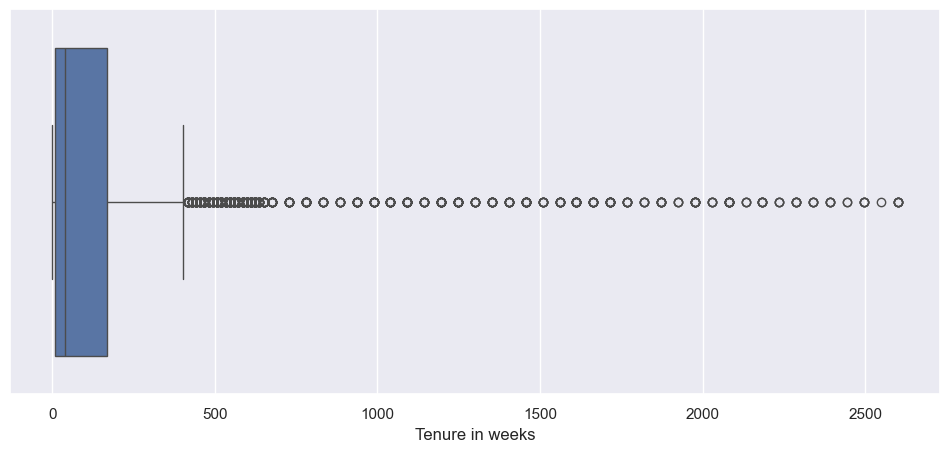

In [35]:
sns.boxplot(x=df['Tenure in weeks'])

<Axes: xlabel='Review Rating'>

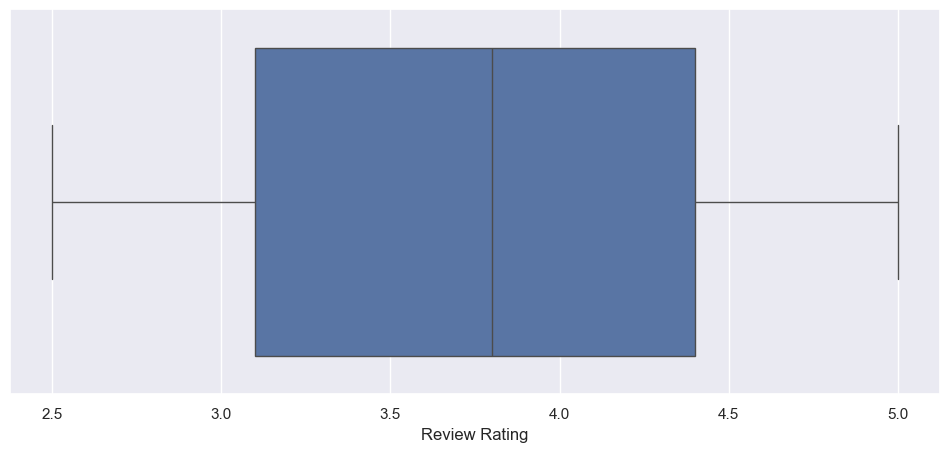

In [36]:
sns.boxplot(x=df['Review Rating'])

<Axes: xlabel='Purchase Amount (USD)'>

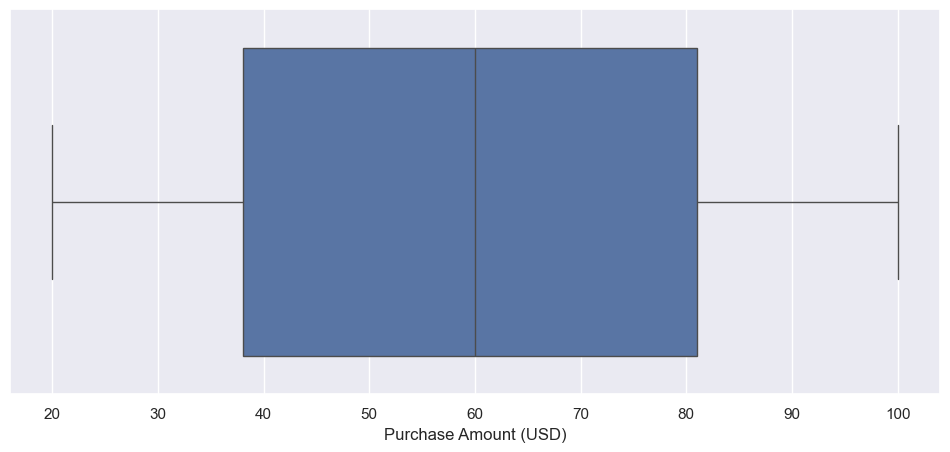

In [37]:
sns.boxplot(x=df['Purchase Amount (USD)'])

<Axes: xlabel='Previous Purchases'>

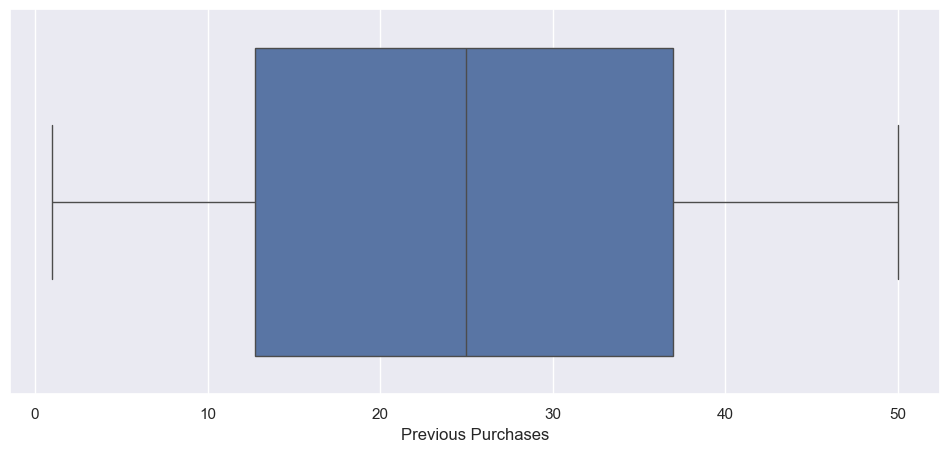

In [38]:
sns.boxplot(x=df['Previous Purchases'])

Frequency of Purchases
Every 3 Months    584
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Annually          452
Name: count, dtype: int64

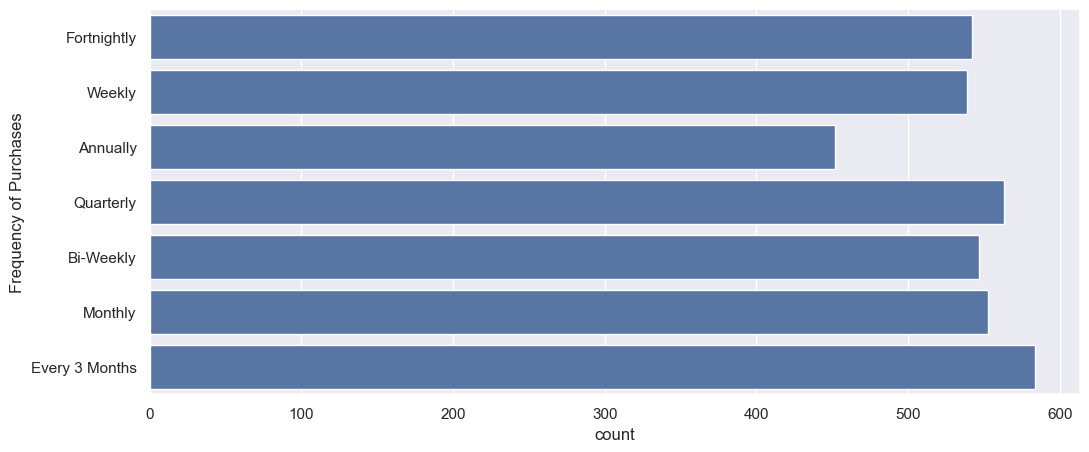

In [39]:
# Frequency distribution after standardization — should show 6 clean categories
sns.countplot(df["Frequency of Purchases"])
df["Frequency of Purchases"].value_counts()

In [40]:
# Edge case check: customers whose age minus tenure (years) is less than 10
# i.e. customers who appear to have started purchasing as very young children
df[df['Age']-df['Tenure in weeks']/52 <10 ]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
25,26,18,Male,Hoodie,Clothing,25,Texas,M,Summer,3.6,Yes,Express,Yes,14,PayPal,Annually,728.0
42,43,20,Male,Coat,Outerwear,100,Tennessee,M,Spring,4.1,Yes,Free Shipping,Yes,15,PayPal,Annually,780.0
71,72,36,Male,Dress,Clothing,48,Virginia,L,Summer,2.9,Yes,Express,Yes,34,Bank Transfer,Annually,1768.0
174,175,41,Male,Shoes,Footwear,35,Vermont,L,Winter,3.5,Yes,Express,Yes,37,Venmo,Annually,1924.0
186,187,39,Male,Backpack,Accessories,56,Minnesota,S,Summer,2.9,Yes,Standard,Yes,31,Debit Card,Annually,1612.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,3773,44,Female,Pants,Clothing,26,New Hampshire,L,Fall,3.1,No,Next Day Air,No,35,Cash,Annually,1820.0
3807,3808,38,Female,Blouse,Clothing,39,Michigan,L,Spring,2.9,No,Next Day Air,No,36,PayPal,Annually,1872.0
3868,3869,18,Female,Dress,Clothing,29,Maryland,XL,Winter,3.3,No,2-Day Shipping,No,9,Cash,Annually,468.0
3889,3890,57,Female,Dress,Clothing,65,Alaska,S,Spring,3.5,No,Express,No,49,Bank Transfer,Annually,2548.0


In [41]:
# Confirm no remaining impossible tenure rows
df[df['Tenure in weeks']/52 >df['Age'] ]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks


In [42]:
# Check youngest customer
df[df['Age']==df['Age'].min()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
24,25,18,Male,Jacket,Outerwear,22,Florida,M,Fall,2.9,Yes,Store Pickup,Yes,16,Debit Card,Weekly,16.0
25,26,18,Male,Hoodie,Clothing,25,Texas,M,Summer,3.6,Yes,Express,Yes,14,PayPal,Annually,728.0
72,73,18,Male,Dress,Clothing,26,Georgia,M,Winter,2.9,Yes,Store Pickup,Yes,21,Bank Transfer,Every 3 Months,0.0
228,229,18,Male,Socks,Clothing,79,New Hampshire,M,Spring,2.9,Yes,Store Pickup,Yes,11,Credit Card,Annually,572.0
357,358,18,Male,Belt,Accessories,56,Arkansas,M,Spring,4.0,Yes,Standard,Yes,16,Credit Card,Bi-Weekly,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3610,3611,18,Female,Jacket,Outerwear,86,Texas,XL,Fall,4.8,No,2-Day Shipping,No,23,Bank Transfer,Fortnightly,46.0
3714,3715,18,Female,Hat,Accessories,31,New York,S,Winter,3.9,No,Express,No,35,Credit Card,Weekly,35.0
3725,3726,18,Female,Dress,Clothing,100,Oklahoma,S,Winter,4.4,No,Next Day Air,No,2,PayPal,Annually,104.0
3806,3807,18,Female,Boots,Footwear,71,Missouri,M,Spring,3.0,No,Standard,No,41,PayPal,Weekly,41.0


In [43]:
# Check oldest customer
df[df['Age']==df['Age'].max()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
39,40,70,Male,Pants,Clothing,60,Arizona,S,Summer,4.2,Yes,Express,Yes,18,Credit Card,Monthly,72.0
108,109,70,Male,Socks,Clothing,79,Montana,L,Spring,3.4,Yes,Next Day Air,Yes,32,Bank Transfer,Bi-Weekly,16.0
114,115,70,Male,Coat,Outerwear,95,Massachusetts,S,Summer,3.7,Yes,Store Pickup,Yes,9,Cash,Weekly,9.0
203,204,70,Male,Scarf,Accessories,38,Indiana,S,Fall,3.2,Yes,Next Day Air,Yes,18,Bank Transfer,Weekly,18.0
229,230,70,Male,Sandals,Footwear,28,Ohio,S,Spring,4.6,Yes,Next Day Air,Yes,27,PayPal,Every 3 Months,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3675,3676,70,Female,Hat,Accessories,80,Virginia,M,Winter,4.5,No,Express,No,3,Bank Transfer,Monthly,12.0
3802,3803,70,Female,Scarf,Accessories,72,Illinois,S,Spring,3.2,No,2-Day Shipping,No,1,Bank Transfer,Monthly,4.0
3818,3819,70,Female,Sneakers,Footwear,41,Oregon,XL,Winter,3.8,No,Free Shipping,No,42,Cash,Monthly,168.0
3822,3823,70,Female,Hat,Accessories,41,Kansas,S,Spring,3.2,No,Free Shipping,No,17,PayPal,Every 3 Months,0.0


(array([377., 357., 354., 347., 370., 416., 381., 390., 361., 427.]),
 array([18. , 23.2, 28.4, 33.6, 38.8, 44. , 49.2, 54.4, 59.6, 64.8, 70. ]),
 <BarContainer object of 10 artists>)

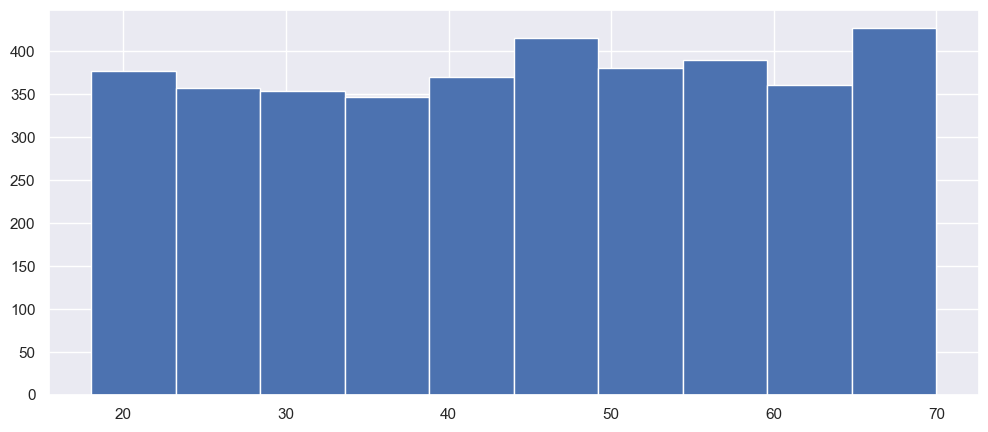

In [44]:
plt.hist(df['Age'])

In [45]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Tenure in weeks
count,3780.000000,3780.000000,3780.000000,3744.000000,3780.000000,3780.000000
mean,1951.258201,44.547884,59.671164,3.749653,24.914550,208.197751
std,1125.205134,15.137373,23.716529,0.717031,14.386799,416.320664
min,1.000000,18.000000,20.000000,2.500000,1.000000,0.000000
25%,977.750000,31.000000,38.000000,3.100000,12.750000,9.000000
50%,1946.500000,45.000000,60.000000,3.800000,25.000000,39.000000
75%,2929.250000,57.000000,81.000000,4.400000,37.000000,168.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,2600.000000


In [46]:
# Review Rating skew — close to 0 confirms approximately symmetric distribution
df['Review Rating'].skew()

np.float64(0.00021994737830990048)

In [47]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,28.0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,4.0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,23.0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,49.0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,1612.0


<Axes: xlabel='Review Rating', ylabel='Tenure in weeks'>

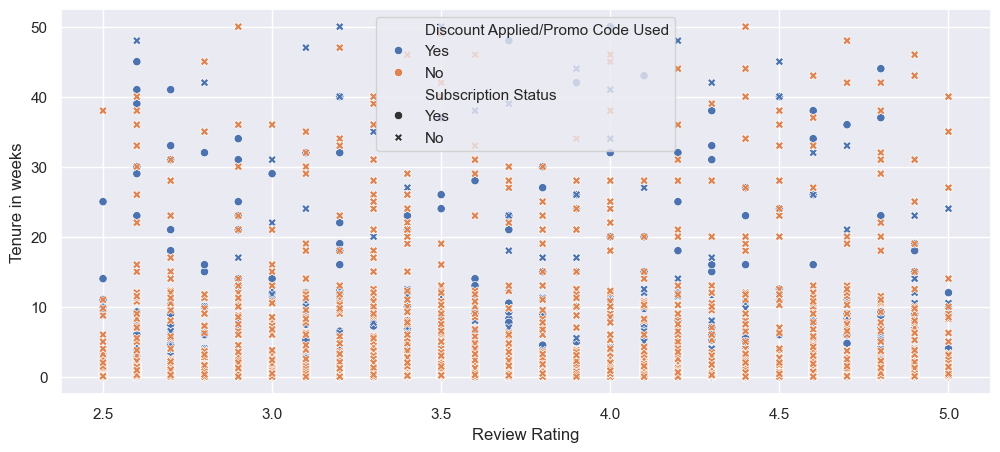

In [48]:
# Rating vs Tenure coloured by discount and subscription
# Satisfaction independent of tenure/promo behaviour
sns.scatterplot(x=df["Review Rating"],y=df["Tenure in weeks"]/52,hue=df['Discount Applied/Promo Code Used'],style=df["Subscription Status"])

<Axes: xlabel='Subscription Status', ylabel='Tenure in weeks'>

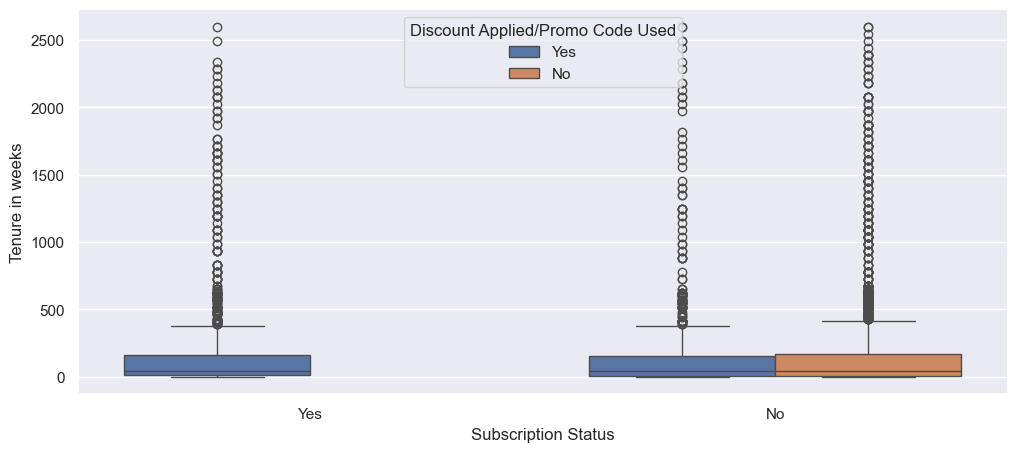

In [49]:
sns.boxplot(x=df['Subscription Status'],y=df['Tenure in weeks'],hue=df['Discount Applied/Promo Code Used'])

<Axes: xlabel='Subscription Status', ylabel='Tenure in weeks'>

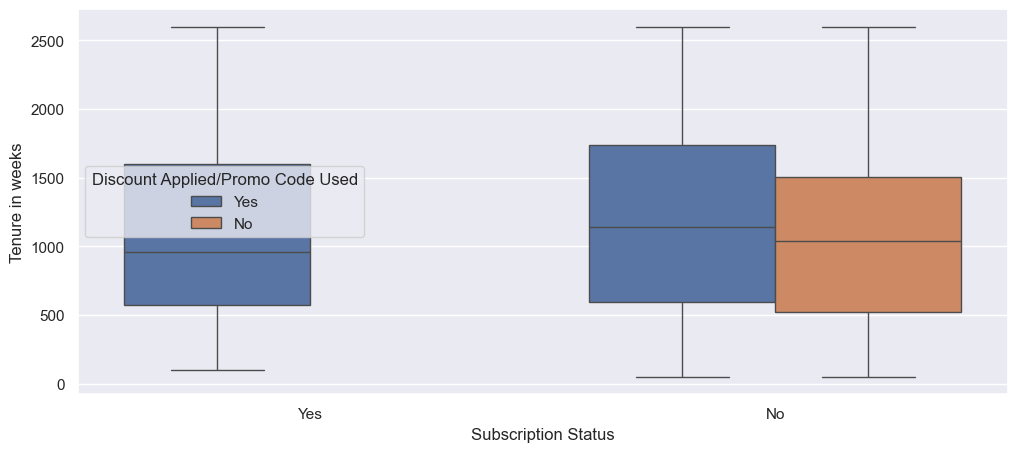

In [50]:
# Annual buyers only: Tenure by subscription and discount
annual_df = df[df["Frequency of Purchases"] == "Annually"]

sns.boxplot(
    data=annual_df,
    x="Subscription Status",
    y="Tenure in weeks",
    hue="Discount Applied/Promo Code Used"
)

In [51]:
# Count nulls in Review Rating
df['Review Rating'].isnull().sum()

np.int64(36)

In [52]:
# Inspect all null-rating rows
df[df['Review Rating'].isnull()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied/Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Tenure in weeks
38,39,29,Male,Dress,Clothing,37,Florida,M,Winter,NaN,Yes,2-Day Shipping,Yes,44,Venmo,Every 3 Months,0.0
50,51,49,Male,Blouse,Clothing,28,Maryland,M,Spring,NaN,Yes,Store Pickup,Yes,39,Debit Card,Bi-Weekly,19.5
80,81,19,Male,Sandals,Footwear,72,New York,XL,Summer,NaN,Yes,Store Pickup,Yes,24,Credit Card,Every 3 Months,0.0
96,97,32,Male,Gloves,Accessories,73,Delaware,S,Spring,NaN,Yes,Express,Yes,43,Venmo,Every 3 Months,0.0
262,263,37,Male,Pants,Clothing,40,Hawaii,M,Summer,NaN,Yes,Next Day Air,Yes,6,Debit Card,Annually,312.0
330,331,46,Male,Sweater,Clothing,51,North Dakota,M,Winter,NaN,Yes,Express,Yes,43,Venmo,Bi-Weekly,21.5
356,357,56,Male,Pants,Clothing,80,Nevada,L,Spring,NaN,Yes,Standard,Yes,27,Cash,Weekly,27.0
383,384,50,Male,Sunglasses,Accessories,77,West Virginia,S,Fall,NaN,Yes,Standard,Yes,6,PayPal,Quarterly,78.0
419,420,53,Male,Shorts,Clothing,91,Utah,S,Winter,NaN,Yes,Free Shipping,Yes,14,Credit Card,Every 3 Months,0.0
442,443,29,Male,Sunglasses,Accessories,69,Michigan,M,Fall,NaN,Yes,Store Pickup,Yes,31,Credit Card,Quarterly,403.0


In [53]:
# All 36 nulls are Male AND Discount=Yes
print(df[df['Review Rating'].isnull()]['Gender'].value_counts())
print(df[df['Review Rating'].isnull()]['Discount Applied/Promo Code Used'].value_counts())

Gender
Male    36
Name: count, dtype: int64
Discount Applied/Promo Code Used
Yes    36
Name: count, dtype: int64


In [54]:
# null-raters vs rated customers
df[df['Review Rating'].isnull()][['Purchase Amount (USD)','Previous Purchases','Tenure in weeks']].describe()

,Purchase Amount (USD),Previous Purchases,Tenure in weeks
count,36.000000,36.000000,36.000000
mean,66.416667,26.055556,273.625000
std,23.059395,13.852167,509.027804
min,20.000000,2.000000,0.000000
25%,49.750000,14.000000,8.750000
50%,69.000000,27.500000,38.000000
75%,83.500000,39.000000,403.000000
max,100.000000,49.000000,2288.000000


In [55]:
df[df['Review Rating'].isnull() == False][['Purchase Amount (USD)','Previous Purchases','Tenure in weeks']].describe()

,Purchase Amount (USD),Previous Purchases,Tenure in weeks
count,3744.000000,3744.000000,3744.000000
mean,59.606303,24.903579,207.568643
std,23.716441,14.393187,415.361845
min,20.000000,1.000000,0.000000
25%,38.000000,12.000000,9.000000
50%,60.000000,25.000000,39.000000
75%,80.000000,37.000000,168.000000
max,100.000000,50.000000,2600.000000


## MISSING VALUE HANDLING FROM REVIEW RATINGS

In [56]:
# We establish that customers with null review ratings are established subscribed customers, not disengaged bargain hunters
df[df['Review Rating'].isnull()]['Subscription Status'].value_counts()

Subscription Status
Yes    20
No     16
Name: count, dtype: int64

In [57]:
# Overall subscription rate for comparison (27% subscribers overall)
df['Subscription Status'].value_counts(normalize=True)

Subscription Status
No     0.730423
Yes    0.269577
Name: proportion, dtype: float64

In [58]:
# Check frequency distribution among null-raters
# Concentrated in Quarterly/Annual — lower-frequency, higher-ticket buyers
df[df['Review Rating'].isnull()]['Frequency of Purchases'].value_counts()

Frequency of Purchases
Every 3 Months    7
Annually          6
Quarterly         6
Bi-Weekly         5
Monthly           5
Weekly            4
Fortnightly       3
Name: count, dtype: int64

In [59]:
# Step 1: Flag missing ratings BEFORE imputation — preserves behavioral signal.
# rating_missing=1 identifies the low-review-engagement subscriber subgroup.

df['rating_missing'] = df['Review Rating'].isnull().astype(int)

# Step 2: Frequency-group median imputation.
# Per-frequency medians (3.7-3.8)are nearly identical
# is invariant across frequency in this dataset. Group-wise imputation
df['Review Rating'] = df.groupby('Frequency of Purchases')['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)
print(df['Review Rating'].isnull().sum())  # should be 0
print(df.groupby('Frequency of Purchases')['Review Rating'].median())

0
Frequency of Purchases
Annually          3.8
Bi-Weekly         3.7
Every 3 Months    3.8
Fortnightly       3.7
Monthly           3.8
Quarterly         3.6
Weekly            3.8
Name: Review Rating, dtype: float64


In [60]:
df.groupby(["Subscription Status", "Discount Applied/Promo Code Used"]).size().reset_index(name="Count")

,Subscription Status,Discount Applied/Promo Code Used,Count
0,No,No,2152
1,No,Yes,609
2,Yes,Yes,1019


In [87]:
# yearly_purchase_rate: how many times does this customer buy per year?
# Weekly=52, Bi-Weekly=104 (twice a week), Fortnightly=26 (once a fortnight)
# Monthly=12, Quarterly=4, Annually=1

frequency_map = {
    'Weekly'         : 52,
    'Bi-Weekly'      : 104,
    'Fortnightly'    : 26,
    'Monthly'        : 12,
    'Quarterly'      : 4,
    'Every 3 Months' : 4,   # folded into Quarterly (same cadence)
    'Annually'       : 1
}

df['yearly_purchase_rate'] = df['Frequency of Purchases'].map(frequency_map)

print(df['yearly_purchase_rate'].isnull().sum())  # should be 0
print(df['yearly_purchase_rate'].value_counts().sort_index())

0
yearly_purchase_rate
1       452
4      1147
12      553
26      542
52      539
104     547
Name: count, dtype: int64


In [88]:
# Duplicate row check — none expected after cleaning
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Customer ID, Age, Gender, Item Purchased, Category, Purchase Amount (USD), Location, Size, Season, Review Rating, Subscription Status, Shipping Type, Discount Applied/Promo Code Used, Previous Purchases, Payment Method, Frequency of Purchases, Tenure in weeks, rating_missing, yearly_purchase_rate, spend_normalized, engagement_normalized, frequency_normalized, subscription_binary, clv_score, clv_tier, consistent, customer_segment, prev_purchases_normalized, consistency_score, discount_flag, commitment_factor, dependency_score, loyalty_A, loyalty_B, rev_proxy, top_A, top_B, loyalty_score, loyalty_tier, full_price_buyer, rating_normalized, satisfaction_tier]
Index: []

[0 rows x 42 columns]


## TO DEFINE AND CALCULATE CLV SCORES AND CLV TIERS


In [89]:
# Normalize CLV components to 0-1 for comparability
# subscription_binary created here for correlation analysis only, excluded from CLV score as its availed to access discount
scaler = MinMaxScaler()

df['spend_normalized'] = scaler.fit_transform(df[['Purchase Amount (USD)']])
df['engagement_normalized'] = scaler.fit_transform(df[['Previous Purchases']])
df['frequency_normalized'] = scaler.fit_transform(df[['yearly_purchase_rate']])
df['subscription_binary'] = (df['Subscription Status'] == 'Yes').astype(int)

# Correlation analysis: which components predict Previous Purchases (loyalty proxy)?
# Result: all near-zero (max r=0.031) -> no component outperforms others
components = ['spend_normalized', 'engagement_normalized',
              'frequency_normalized', 'subscription_binary']

print("=== Correlation with Previous Purchases ===")
print(df[components].corrwith(df['Previous Purchases']).sort_values(ascending=False))

print("\n=== Correlation Matrix between components ===")
print(df[components + ['Previous Purchases']].corr().round(3))

=== Correlation with Previous Purchases ===
engagement_normalized    1.000000
subscription_binary      0.031045
frequency_normalized     0.014151
spend_normalized         0.006097
dtype: float64

=== Correlation Matrix between components ===
                       spend_normalized  engagement_normalized  \
spend_normalized                  1.000                  0.006   
engagement_normalized             0.006                  1.000   
frequency_normalized              0.009                  0.014   
subscription_binary              -0.005                  0.031   
Previous Purchases                0.006                  1.000   

                       frequency_normalized  subscription_binary  \
spend_normalized                      0.009               -0.005   
engagement_normalized                 0.014                0.031   
frequency_normalized                  1.000               -0.001   
subscription_binary                  -0.001                1.000   
Previous Purchases   

In [90]:
# CLV Score 
# Weights: engagement 0.40 (most accumulated signal), frequency 0.35,
# spend 0.25 (single transaction, noisier proxy for average order value)
# Theory-justified weights: correlation analysis showed no statistical basis for differential weighting across components
# subscription excluded (discount-access signal, not commitment)
df['clv_score'] = (
    0.40 * df['engagement_normalized'] +
    0.35 * df['frequency_normalized'] +
    0.25 * df['spend_normalized']
)

# Tier into Low/Mid/High using equal percentile cuts (pd.qcut, q=3)
# Each tier contains exactly 1/3 of customers by construction
df['clv_tier'] = pd.qcut(df['clv_score'], q=3, labels=['Low', 'Mid', 'High'])

print(df['clv_tier'].value_counts())
print(df.groupby('clv_tier', observed=False)['clv_score'].describe())

clv_tier
Low     1260
Mid     1260
High    1260
Name: count, dtype: int64
           count      mean       std       min       25%       50%       75%  \
clv_tier                                                                       
Low       1260.0  0.218819  0.072586  0.013319  0.173325  0.232492  0.278596   
Mid       1260.0  0.403070  0.048366  0.320414  0.360755  0.403232  0.444601   
High      1260.0  0.623997  0.109851  0.488480  0.537908  0.594135  0.684319   

               max  
clv_tier            
Low       0.320398  
Mid       0.488202  
High      0.993750  


## DEFINING CONSISTENCY 

In [91]:
# CONSISTENCY ATTEMPT 1: dual independent median thresholds (REJECTED)
# Documented for methodological transparency; superseded by continuous score below.
# Problem: requiring BOTH medians simultaneously; A customer moderately strong on both fails if either is below median.
median_prev = df['Previous Purchases'].median()
median_freq = df['yearly_purchase_rate'].median()

print(f"Median Previous Purchases: {median_prev}")
print(f"Median yearly_purchase_rate: {median_freq}")

# Temporary consistent flag for crosstab — will be overwritten below
df['consistent'] = ((df['yearly_purchase_rate'] >= median_freq) &
                    (df['Previous Purchases'] >= median_prev))

pd.crosstab(df['Discount Applied/Promo Code Used'],
            df['consistent'],
            margins=True)

Median Previous Purchases: 25.0
Median yearly_purchase_rate: 12.0


consistent,False,True,All
Discount Applied/Promo Code Used,,,
No,1525,627,2152
Yes,1127,501,1628
All,2652,1128,3780


In [92]:
# Segmentation using rejected dual-threshold consistency (for documentation only)
conditions = [
    (df['Discount Applied/Promo Code Used'] == 'No') & (df['consistent'] == True),
    (df['Discount Applied/Promo Code Used'] == 'Yes') & (df['consistent'] == True),
    (df['Discount Applied/Promo Code Used'] == 'No') & (df['consistent'] == False),
    (df['Discount Applied/Promo Code Used'] == 'Yes') & (df['consistent'] == False),
]

labels = [
    'Loyal: Brand Purist',
    'Loyal: Promo Dependent',
    'Casual: Organic',
    'Casual: Bargain Hunter'
]

df['customer_segment'] = np.select(conditions, labels, default='Unknown')

print(df['customer_segment'].value_counts())

customer_segment
Casual: Organic           1525
Casual: Bargain Hunter    1127
Loyal: Brand Purist        627
Loyal: Promo Dependent     501
Name: count, dtype: int64


count    3780.000000
mean       29.281481
std        34.880223
min         1.000000
25%         4.000000
50%        12.000000
75%        52.000000
max       104.000000
Name: yearly_purchase_rate, dtype: float64

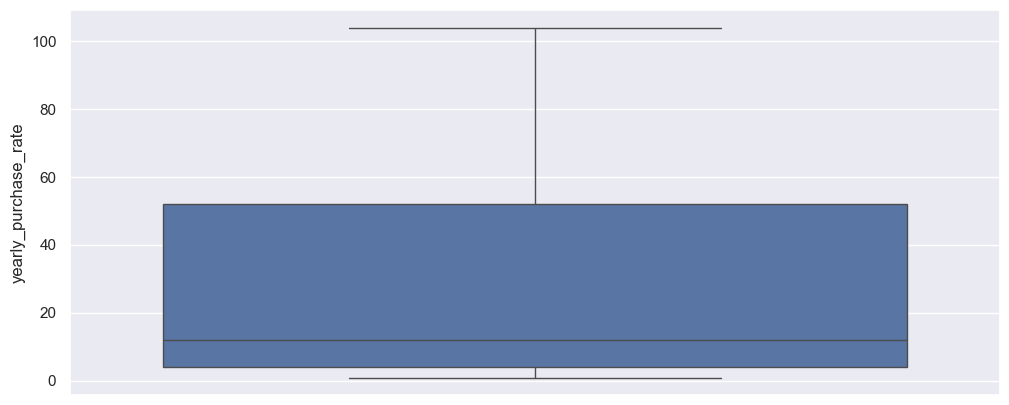

In [93]:
sns.boxplot(df['yearly_purchase_rate'])
df['yearly_purchase_rate'].describe()

<Axes: ylabel='Previous Purchases'>

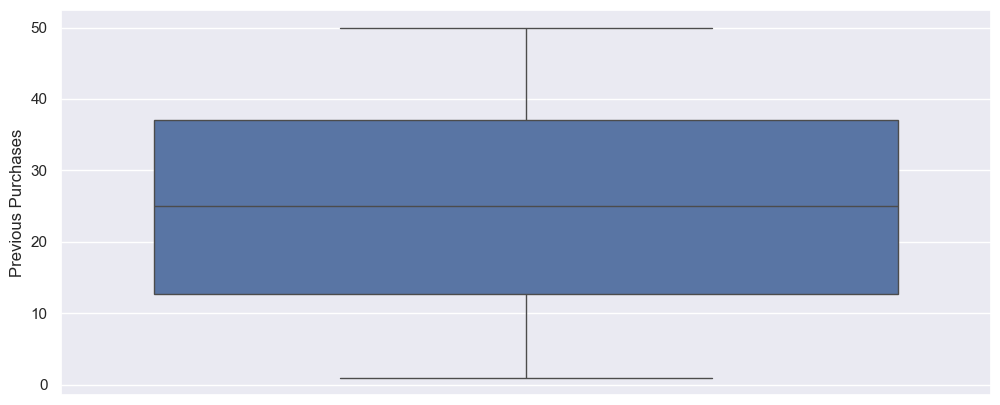

In [94]:
sns.boxplot(df['Previous Purchases'])

In [95]:
# CONSISTENCY ATTEMPT 2: continuous composite score (ADOPTED)
# Addresses dual-threshold limitation: strength on one dimension can partially compensate for weakness on another.
# Equal weights: both frequency and purchase depth are equally necessary to define consistency. Subscription excluded as its a discount-access signal.
df['prev_purchases_normalized'] = scaler.fit_transform(df[['Previous Purchases']])

df['consistency_score'] = (
    0.5 * df['prev_purchases_normalized'] +
    0.5 * df['frequency_normalized']
)

# Binary flag derived from composite score median (not two independent medians)
# Results in near-50/50 split: 1904 consistent vs 1876 inconsistent
consistency_threshold = df['consistency_score'].median()
df['consistent'] = (df['consistency_score'] >= consistency_threshold).astype(int)

print("=== Consistency Score Distribution ===")
print(df['consistency_score'].describe())
print(f"\nConsistency threshold (median): {consistency_threshold:.4f}")
print(f"\n=== Consistent Flag Counts ===")
print(df['consistent'].value_counts())
print(f"\nPrevious consistent count (dual threshold) was 1128")

=== Consistency Score Distribution ===
count    3780.000000
mean        0.381315
std         0.225665
min         0.000000
25%         0.208441
50%         0.361502
75%         0.514563
max         1.000000
Name: consistency_score, dtype: float64

Consistency threshold (median): 0.3615

=== Consistent Flag Counts ===
consistent
1    1904
0    1876
Name: count, dtype: int64

Previous consistent count (dual threshold) was 1128


## SUBDIVING CUSTOMERS

In [96]:
# Final 4-way customer segmentation: Promo Usage x Consistency
# Uses ADOPTED continuous consistency score 
# Loyal = consistent (above median composite score)
# Brand Purist = consistent + no discount (genuine organic loyalty)
# Promo Dependent = consistent + discount (engaged but incentive-driven)
# Casual Organic = inconsistent + no discount (occasional full-price buyers)
# Casual Bargain Hunter = inconsistent + discount (purely transactional)
conditions = [
    (df['Discount Applied/Promo Code Used'] == 'No') & (df['consistent'] == 1),
    (df['Discount Applied/Promo Code Used'] == 'Yes') & (df['consistent'] == 1),
    (df['Discount Applied/Promo Code Used'] == 'No') & (df['consistent'] == 0),
    (df['Discount Applied/Promo Code Used'] == 'Yes') & (df['consistent'] == 0),
]

labels = [
    'Loyal: Brand Purist',
    'Loyal: Promo Dependent',
    'Casual: Organic',
    'Casual: Bargain Hunter'
]

df['customer_segment'] = np.select(conditions, labels, default='Unknown')

print(df['customer_segment'].value_counts())
print(f"\nAs percentages:")
print((df['customer_segment'].value_counts(normalize=True) * 100).round(1))

customer_segment
Casual: Organic           1079
Loyal: Brand Purist       1073
Loyal: Promo Dependent     831
Casual: Bargain Hunter     797
Name: count, dtype: int64

As percentages:
customer_segment
Casual: Organic           28.5
Loyal: Brand Purist       28.4
Loyal: Promo Dependent    22.0
Casual: Bargain Hunter    21.1
Name: proportion, dtype: float64


In [97]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,...,loyalty_A,loyalty_B,rev_proxy,top_A,top_B,loyalty_score,loyalty_tier,full_price_buyer,rating_normalized,satisfaction_tier
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Winter,3.1,...,0.502675,0.185714,742,1,0,0.185714,Low,0,0.24,Neutral
1,2,19,Male,Sweater,Clothing,64,Maine,L,Winter,3.1,...,0.421042,0.014286,128,0,0,0.014286,Low,0,0.24,Neutral
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Spring,3.1,...,0.648042,0.314286,1679,1,0,0.314286,Low,0,0.24,Neutral
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Spring,3.5,...,0.824912,0.685714,4410,1,0,0.685714,High,0,0.40,Neutral
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Spring,2.7,...,0.537415,0.428571,1519,1,0,0.428571,Mid,0,0.08,Dissatisfied


In [98]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Tenure in weeks,rating_missing,yearly_purchase_rate,spend_normalized,engagement_normalized,...,commitment_factor,dependency_score,loyalty_A,loyalty_B,rev_proxy,top_A,top_B,loyalty_score,full_price_buyer,rating_normalized
count,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,...,3196.000000,3196.000000,3196.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000
mean,1951.258201,44.547884,59.671164,3.749603,24.914550,208.197751,0.009524,29.281481,0.495890,0.488052,...,0.403654,0.254401,0.359320,0.512430,1488.760053,0.212169,0.259788,0.512430,0.569312,0.499841
std,1125.205134,15.137373,23.716529,0.713646,14.386799,416.320664,0.097137,34.880223,0.296457,0.293608,...,0.229744,0.330189,0.214433,0.250733,1107.853319,0.408898,0.438576,0.250733,0.495238,0.285458
min,1.000000,18.000000,20.000000,2.500000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,977.750000,31.000000,38.000000,3.100000,12.750000,9.000000,0.000000,4.000000,0.225000,0.239796,...,0.228849,0.000000,0.186579,0.342857,597.250000,0.000000,0.000000,0.342857,0.000000,0.240000
50%,1946.500000,45.000000,60.000000,3.800000,25.000000,39.000000,0.000000,12.000000,0.500000,0.489796,...,0.386665,0.000000,0.335018,0.514286,1241.000000,0.000000,0.000000,0.514286,1.000000,0.520000
75%,2929.250000,57.000000,81.000000,4.400000,37.000000,168.000000,0.000000,52.000000,0.762500,0.734694,...,0.545101,0.558550,0.502675,0.685714,2158.500000,0.000000,1.000000,0.685714,1.000000,0.760000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,2600.000000,1.000000,104.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,5000.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [99]:
# Confirm subscription and consistency are independent signals
# Mean consistency scores: No=0.379, Yes=0.389 
# Confirms subscription exclusion from consistency was correct: subscribing does not predict more consistent purchase behaviour
print(df.groupby('Subscription Status')['consistency_score'].describe().round(3))

                      count   mean    std   min    25%    50%    75%  max
Subscription Status                                                      
No                   2761.0  0.379  0.225  0.00  0.204  0.360  0.515  1.0
Yes                  1019.0  0.389  0.227  0.01  0.219  0.372  0.515  1.0


In [100]:
# Prep binary columns
df['discount_flag'] = (df['Discount Applied/Promo Code Used'] == 'Yes').astype(int)
df['subscription_binary'] = (df['Subscription Status'] == 'Yes').astype(int)

# commitment_factor = consistency_score only
# subscription excluded: r=-0.698 with full_price_buyer confirms subscription is a discount-access signal, including it would reduce dependency scores for the brand's most discount-reliant customers
df['commitment_factor'] = df['consistency_score']

# dependency = discount_flag x (1 - commitment)
# Non-discount users: 0 (no dependency to measure)
# Discount users: higher consistency -> lower dependency (opportunistic, not structural)
df['dependency_score'] = df['discount_flag'] * (1 - df['commitment_factor'])

print('=== Dependency Score ===')
print(df['dependency_score'].describe().round(3))
print('\n=== Mean Dependency by Segment ===')
print(df.groupby('customer_segment')['dependency_score'].mean().round(3).sort_values(ascending=False))

=== Dependency Score ===
count    3780.000
mean        0.266
std         0.339
min         0.000
25%         0.000
50%         0.000
75%         0.587
max         1.000
Name: dependency_score, dtype: float64

=== Mean Dependency by Segment ===
customer_segment
Casual: Bargain Hunter    0.802
Loyal: Promo Dependent    0.438
Casual: Organic           0.000
Loyal: Brand Purist       0.000
Name: dependency_score, dtype: float64


## DEFINING LOYALTY 

In [101]:
# LOYALTY DEFINITION A — Behavioral [CHALLENGER, NOT ADOPTED]
# frequency + engagement + subscription, equal thirds
# Problem discovered in comparison test: A's top loyalists are ~81% discount users and ~77% subscribers 
# A rewards discount-access behaviour, not loyalty
df['loyalty_A'] = (
    df['engagement_normalized'] +
    df['frequency_normalized'] +
    df['subscription_binary']
) / 3

# LOYALTY DEFINITION B — Margin [ADOPTED]
# engagement (0.7): more reliable than single transaction
# (1 - discount_flag) (0.3): full-price willingness, accounts for margin loyalty
# Weighted unequally: accumulated history outweighs single transaction discount observation
df['loyalty_B'] = 0.7 * df['engagement_normalized'] + 0.3 * (1 - df['discount_flag'])

# Comparison test: which definition better serves the brand's question?
df['rev_proxy'] = df['Purchase Amount (USD)'] * df['Previous Purchases']
print('LOYALTY DEFINITION COMPARISON')
print(f"Divergence   corr(A, B)          = {df['loyalty_A'].corr(df['loyalty_B']):.3f}")
print(f"Revenue*     corr(A, rev_proxy)  = {df['loyalty_A'].corr(df['rev_proxy']):.3f}")
print(f"Revenue*     corr(B, rev_proxy)  = {df['loyalty_B'].corr(df['rev_proxy']):.3f}")
print(f"Redundancy   corr(A, commitment) = {df['loyalty_A'].corr(df['commitment_factor']):.3f}")
print('  *revenue proxy = spend x prev_purchases; partly circular -> supporting evidence only')

df['top_A'] = (df['loyalty_A'] >= df['loyalty_A'].quantile(0.75)).astype(int)
df['top_B'] = (df['loyalty_B'] >= df['loyalty_B'].quantile(0.75)).astype(int)
print("\nWHO each definition crowns as 'most loyal' (top quartile):")
for name, mask in [('A (Behavioral)', df['top_A'] == 1), ('B (Margin)', df['top_B'] == 1)]:
    s = df[mask]
    print(f"  Top-{name:14s}: {100*s['discount_flag'].mean():4.0f}% discount | "
          f"{100*s['subscription_binary'].mean():4.0f}% subscribers | "
          f"{s['Previous Purchases'].mean():4.1f} mean prev purchases")
print(f"  Overlap (top in BOTH): {((df['top_A']==1) & (df['top_B']==1)).sum()} customers")

LOYALTY DEFINITION COMPARISON
Divergence   corr(A, B)          = 0.110
Revenue*     corr(A, rev_proxy)  = 0.384
Revenue*     corr(B, rev_proxy)  = 0.639
Redundancy   corr(A, commitment) = 0.720
  *revenue proxy = spend x prev_purchases; partly circular -> supporting evidence only

WHO each definition crowns as 'most loyal' (top quartile):
  Top-A (Behavioral):   81% discount |   78% subscribers | 32.8 mean prev purchases
  Top-B (Margin)    :    3% discount |    2% subscribers | 38.9 mean prev purchases
  Overlap (top in BOTH): 174 customers


In [102]:
# Adopt Definition B (loyalty_score is loyalty_B going forward)
# B directly answers the margin question
# A's top loyalists are 81% discount users 
# A is largely redundant with commitment_factor (correlation between Loyalty_A and commitment factor comes very high~0.9)
df['loyalty_score'] = df['loyalty_B']
df['loyalty_tier'] = pd.qcut(df['loyalty_score'], q=3, labels=['Low', 'Mid', 'High'])
print(df['loyalty_tier'].value_counts())

loyalty_tier
Mid     1275
Low     1272
High    1233
Name: count, dtype: int64


In [103]:
# Full-price buyer indicator for correlation analysis
df['full_price_buyer'] = (df['discount_flag'] == 0).astype(int)
df['spend_normalized'] = scaler.fit_transform(df[['Purchase Amount (USD)']])
df['rating_normalized'] = scaler.fit_transform(df[['Review Rating']])

candidates = [
    'prev_purchases_normalized',
    'spend_normalized',
    'rating_normalized',
    'subscription_binary',
    'frequency_normalized'
]

# FINDING: subscription_binary = -0.698 with full_price_buyer (dominant signal)
# All other candidates near zero (max 0.015)
# Conclusion: no continuous variable predicts full-price buying
# discount usage is structurally driven by subscription status
print("=== Correlation with Full Price Buying ===")
print(df[candidates].corrwith(df['full_price_buyer']).sort_values(ascending=False).round(3))

print("\n=== Correlation Matrix Between Candidates ===")
print(df[candidates + ['full_price_buyer']].corr().round(3))

print("\n=== Mean values — Discount vs No Discount ===")
print(df.groupby('discount_flag')[candidates].mean().round(3))

=== Correlation with Full Price Buying ===
spend_normalized             0.015
rating_normalized            0.010
frequency_normalized         0.010
prev_purchases_normalized   -0.024
subscription_binary         -0.698
dtype: float64

=== Correlation Matrix Between Candidates ===
                           prev_purchases_normalized  spend_normalized  \
prev_purchases_normalized                      1.000             0.006   
spend_normalized                               0.006             1.000   
rating_normalized                              0.004             0.026   
subscription_binary                            0.031            -0.005   
frequency_normalized                           0.014             0.009   
full_price_buyer                              -0.024             0.015   

                           rating_normalized  subscription_binary  \
prev_purchases_normalized              0.004                0.031   
spend_normalized                       0.026               -0.0

In [104]:
# Standalone subscription finding
# Subscribers account for 62.6% of discount users while representing
# virtually no full-price buyers — subscription program functions as
# discount access mechanism, not loyalty driver
print("=== Subscription = Discount Access Signal ===")
print(df.groupby('Subscription Status')[
    ['dependency_score', 'loyalty_score', 'clv_score']
].mean().round(3))

print("\n=== Discount usage by Subscription Status ===")
print(pd.crosstab(df['Subscription Status'],
                  df['Discount Applied/Promo Code Used'],
                  normalize='index').round(3))

=== Subscription = Discount Access Signal ===
                     dependency_score  loyalty_score  clv_score
Subscription Status                                            
No                              0.138          0.572      0.413
Yes                             0.611          0.352      0.421

=== Discount usage by Subscription Status ===
Discount Applied/Promo Code Used     No    Yes
Subscription Status                           
No                                0.779  0.221
Yes                               0.000  1.000


In [105]:
# CLV sensitivity: with vs without subscription_binary
# Demonstrates that subscription contaminated the original CLV ranking
df['clv_score_with_sub'] = (
    0.35 * df['engagement_normalized'] +
    0.30 * df['frequency_normalized'] +
    0.20 * df['spend_normalized'] +
    0.15 * df['subscription_binary']
)

df['clv_tier_with_sub'] = pd.qcut(
    df['clv_score_with_sub'], q=3, labels=['Low', 'Mid', 'High']
)

print("=== CLV Score Means by Segment: WITH subscription (rejected) ===")
print(df.groupby('customer_segment')['clv_score_with_sub'].mean().round(3).sort_values(ascending=False))

print("\n=== CLV Score Means by Segment: WITHOUT subscription (adopted) ===")
print(df.groupby('customer_segment')['clv_score'].mean().round(3).sort_values(ascending=False))

print("\n=== CLV Tier distribution WITH subscription (rejected) ===")
print(pd.crosstab(df['customer_segment'], df['clv_tier_with_sub'], normalize='index').round(3))

print("\n=== CLV Tier distribution WITHOUT subscription (adopted) ===")
print(pd.crosstab(df['customer_segment'], df['clv_tier'], normalize='index').round(3))

# Drop comparison columns — not part of final deliverable
df = df.drop(columns=['clv_score_with_sub', 'clv_tier_with_sub'])

=== CLV Score Means by Segment: WITH subscription (rejected) ===
customer_segment
Loyal: Promo Dependent    0.567
Loyal: Brand Purist       0.472
Casual: Bargain Hunter    0.322
Casual: Organic           0.232
Name: clv_score_with_sub, dtype: float64

=== CLV Score Means by Segment: WITHOUT subscription (adopted) ===
customer_segment
Loyal: Brand Purist       0.554
Loyal: Promo Dependent    0.552
Casual: Organic           0.276
Casual: Bargain Hunter    0.274
Name: clv_score, dtype: float64

=== CLV Tier distribution WITH subscription (rejected) ===
clv_tier_with_sub         Low    Mid   High
customer_segment                           
Casual: Bargain Hunter  0.427  0.453  0.120
Casual: Organic         0.797  0.203  0.000
Loyal: Brand Purist     0.037  0.480  0.483
Loyal: Promo Dependent  0.024  0.199  0.777

=== CLV Tier distribution WITHOUT subscription (adopted) ===
clv_tier                  Low    Mid   High
customer_segment                           
Casual: Bargain Hunter  0.671 

## SATISFACTION TIER

In [106]:
# Check proposed tier thresholds before finalizing
# Confirms Highly Dissatisfied (<2.0) is empty 
rated = df[df['rating_missing'] == 0]['Review Rating']

print("=== Proposed Tier Distribution ===")
print(f"Highly Satisfied (>=4.0)       : {(rated >= 4.0).sum()} ({(rated >= 4.0).mean()*100:.1f}%)")
print(f"Neutral (3.0-4.0)              : {((rated >= 3.0) & (rated < 4.0)).sum()} ({((rated >= 3.0) & (rated < 4.0)).mean()*100:.1f}%)")
print(f"Dissatisfied (2.0-3.0)         : {((rated >= 2.0) & (rated < 3.0)).sum()} ({((rated >= 2.0) & (rated < 3.0)).mean()*100:.1f}%)")
print(f"Highly Dissatisfied (<2.0)     : {(rated < 2.0).sum()} ({(rated < 2.0).mean()*100:.1f}%)")
print(f"Unrated                        : {df['rating_missing'].sum()} ({df['rating_missing'].mean()*100:.1f}%)")
print(f"\nTotal: {len(df)}")
print(f"\nRating range: {rated.min()} to {rated.max()}")

=== Proposed Tier Distribution ===
Highly Satisfied (>=4.0)       : 1586 (42.4%)
Neutral (3.0-4.0)              : 1496 (40.0%)
Dissatisfied (2.0-3.0)         : 662 (17.7%)
Highly Dissatisfied (<2.0)     : 0 (0.0%)
Unrated                        : 36 (1.0%)

Total: 3780

Rating range: 2.5 to 5.0


In [107]:
# Satisfaction tier using imputed Review Rating for all customers.
# Originally-missing ratings were imputed with frequency-group median (3.7-3.8)
# which correctly places them in Neutral — consistent with their
# established profile (high-spend subscribers who don't engage with reviews).
# Three tiers: Dissatisfied <3.0, Neutral 3.0-4.0, Highly Satisfied >=4.0
df['satisfaction_tier'] = pd.cut(
    df['Review Rating'],
    bins=[0, 3.0, 4.0, 5.0],
    labels=['Dissatisfied', 'Neutral', 'Highly Satisfied'],
    include_lowest=True
)

print("=== Satisfaction Tier Distribution ===")
print(df['satisfaction_tier'].value_counts())
print(f"\nAs percentages:")
print((df['satisfaction_tier'].value_counts(normalize=True) * 100).round(1))

# FINDING: Satisfaction is uniform across segments and CLV tiers (variation <3.5pp)
# Satisfaction is a standalone quality metric, not a loyalty predictor
print("\n=== Satisfaction by Customer Segment ===")
print(pd.crosstab(df['customer_segment'],
                  df['satisfaction_tier'],
                  normalize='index').round(3))

print("\n=== Satisfaction by CLV Tier ===")
print(pd.crosstab(df['clv_tier'],
                  df['satisfaction_tier'],
                  normalize='index').round(3))

=== Satisfaction Tier Distribution ===
satisfaction_tier
Neutral             1552
Highly Satisfied    1411
Dissatisfied         817
Name: count, dtype: int64

As percentages:
satisfaction_tier
Neutral             41.1
Highly Satisfied    37.3
Dissatisfied        21.6
Name: proportion, dtype: float64

=== Satisfaction by Customer Segment ===
satisfaction_tier       Dissatisfied  Neutral  Highly Satisfied
customer_segment                                               
Casual: Bargain Hunter         0.223    0.398             0.379
Casual: Organic                0.204    0.426             0.370
Loyal: Brand Purist            0.223    0.392             0.385
Loyal: Promo Dependent         0.217    0.426             0.357

=== Satisfaction by CLV Tier ===
satisfaction_tier  Dissatisfied  Neutral  Highly Satisfied
clv_tier                                                  
Low                       0.213    0.415             0.371
Mid                       0.225    0.399             0.375
Hig

## SEGMENT PROFILE

In [108]:
print('Segment profile (mean dependency / loyalty / CLV):')
print(df.groupby('customer_segment')[['dependency_score','loyalty_score','clv_score']].mean().round(3))

engineered = ['discount_flag','subscription_binary','yearly_purchase_rate',
              'spend_normalized','engagement_normalized','frequency_normalized',
              'consistency_score','consistent','commitment_factor',
              'clv_score','clv_tier','dependency_score',
              'loyalty_A','loyalty_B','loyalty_score','loyalty_tier',
              'customer_segment','rating_missing']
print('\nEngineered columns present:')
print([c for c in engineered if c in df.columns])

Segment profile (mean dependency / loyalty / CLV):
                        dependency_score  loyalty_score  clv_score
customer_segment                                                  
Casual: Bargain Hunter             0.802          0.210      0.274
Casual: Organic                    0.000          0.508      0.276
Loyal: Brand Purist                0.000          0.767      0.554
Loyal: Promo Dependent             0.438          0.479      0.552

Engineered columns present:
['discount_flag', 'subscription_binary', 'yearly_purchase_rate', 'spend_normalized', 'engagement_normalized', 'frequency_normalized', 'consistency_score', 'consistent', 'commitment_factor', 'clv_score', 'clv_tier', 'dependency_score', 'loyalty_A', 'loyalty_B', 'loyalty_score', 'loyalty_tier', 'customer_segment', 'rating_missing']


## REMOVING REDUNDANT COLUMNS

In [109]:
# Final column selection 
# Intermediate normalized columns excluded (already consumed by scores)
# subscription_binary, discount_flag excluded (SQL can derive from raw columns)
# top_A, top_B, loyalty_A, loyalty_B, rev_proxy excluded (comparison only)
# commitment_factor excluded (intermediate step, superseded by dependency_score)
final_columns = [
    # Original cleaned columns
    'Customer ID',
    'Age',
    'Gender',
    'Item Purchased',
    'Category',
    'Purchase Amount (USD)',
    'Location',
    'Size',
    'Season',
    'Review Rating',
    'Subscription Status',
    'Shipping Type',
    'Discount Applied/Promo Code Used',
    'Previous Purchases',
    'Payment Method',
    'Frequency of Purchases',
    'Tenure in weeks',
    # Engineered features
    'rating_missing',
    'yearly_purchase_rate',
    'consistency_score',
    'consistent',
    'clv_score',
    'clv_tier',
    'dependency_score',
    'loyalty_score',
    'loyalty_tier',
    'customer_segment',
    'satisfaction_tier',
    
]

df_final = df[final_columns].copy()

print("=== Final Columns ===")
print(df_final.columns.tolist())
print(f"\nShape: {df_final.shape}")

# Null check — all engineered features should be 0
print("\n=== Null Check ===")
print(df_final.isnull().sum())

print("\n=== Engineered Features Sample ===")
print(df_final[['customer_segment', 'clv_tier',
                'loyalty_tier', 'satisfaction_tier',
                'dependency_score', 'consistency_score']].head(10))

df_final.to_csv('final.csv', index=False)
print(f"\nSaved final.csv")
print(f"Rows: {df_final.shape[0]} | Columns: {df_final.shape[1]}")

=== Final Columns ===
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied/Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases', 'Tenure in weeks', 'rating_missing', 'yearly_purchase_rate', 'consistency_score', 'consistent', 'clv_score', 'clv_tier', 'dependency_score', 'loyalty_score', 'loyalty_tier', 'customer_segment', 'satisfaction_tier']

Shape: (3780, 28)

=== Null Check ===
Customer ID                         0
Age                                 0
Gender                              0
Item Purchased                      0
Category                            0
Purchase Amount (USD)               0
Location                            0
Size                                0
Season                              0
Review Rating                       0
Subscription Status                 0
Shipping Type                